In [2]:
! pip install POT

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 867 kB 5.3 MB/s eta 0:00:01


In [ ]:
import scipy as sp
import numpy as np
import matplotlib.pylab as pl
from mpl_toolkits.mplot3d import Axes3D  # noqa
import ot

In [4]:
n_samples = 30  # nb samples

mu_s = np.array([0, 0])
cov_s = np.array([[1, 0], [0, 1]])

mu_t = np.array([4, 4, 4])
cov_t = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])

np.random.seed(0)
xs = ot.datasets.make_2D_samples_gauss(n_samples, mu_s, cov_s)
P = sp.linalg.sqrtm(cov_t)
xt = np.random.randn(n_samples, 3).dot(P) + mu_t

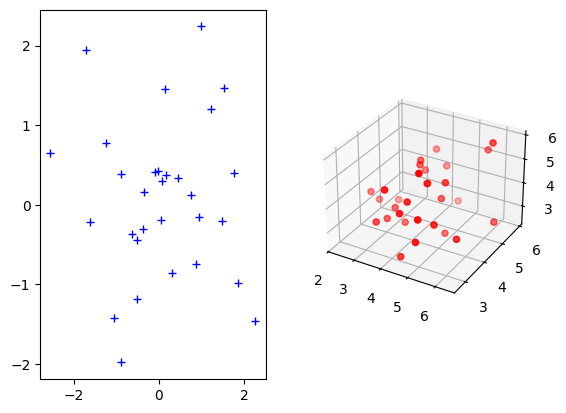

In [5]:
fig = pl.figure(1)
ax1 = fig.add_subplot(121)
ax1.plot(xs[:, 0], xs[:, 1], "+b", label="Source samples")
ax2 = fig.add_subplot(122, projection="3d")
ax2.scatter(xt[:, 0], xt[:, 1], xt[:, 2], color="r")
pl.show()

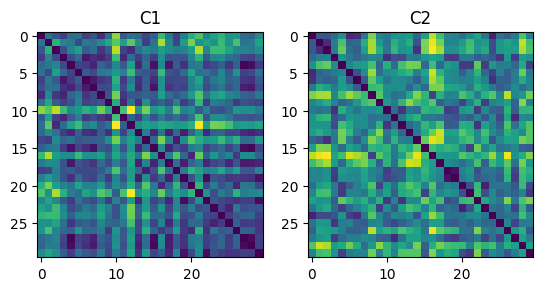

In [6]:
C1 = sp.spatial.distance.cdist(xs, xs)
C2 = sp.spatial.distance.cdist(xt, xt)

C1 /= C1.max()
C2 /= C2.max()

pl.figure(2)
pl.subplot(121)
pl.imshow(C1)
pl.title("C1")

pl.subplot(122)
pl.imshow(C2)
pl.title("C2")

pl.show()

It.  |Loss        |Relative loss|Absolute loss
------------------------------------------------
    0|9.606056e-02|0.000000e+00|0.000000e+00
    1|5.330020e-02|8.022552e-01|4.276036e-02
    2|5.023674e-02|6.098033e-02|3.063453e-03
    3|4.820952e-02|4.205038e-02|2.027228e-03
    4|4.501837e-02|7.088545e-02|3.191147e-03
    5|4.501837e-02|0.000000e+00|0.000000e+00
It.  |Err         
-------------------
    0|8.684324e-02|


/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)


   10|1.209223e-04|
   20|3.076331e-05|
   30|1.140465e-04|
   40|4.876462e-07|
   50|4.040056e-09|
   60|3.334506e-11|
It.  |Err         
-------------------
    0|8.684324e-02|
   10|5.018997e-05|
   20|2.123553e-07|
   30|9.184451e-10|
Gromov-Wasserstein distance estimated with Conditional Gradient solver: 0.0450183690192505
Gromov-Wasserstein distance estimated with Proximal Point solver: 0.03761294147832006
Entropic Gromov-Wasserstein distance estimated with Projected Gradient solver: 0.03823623173438275


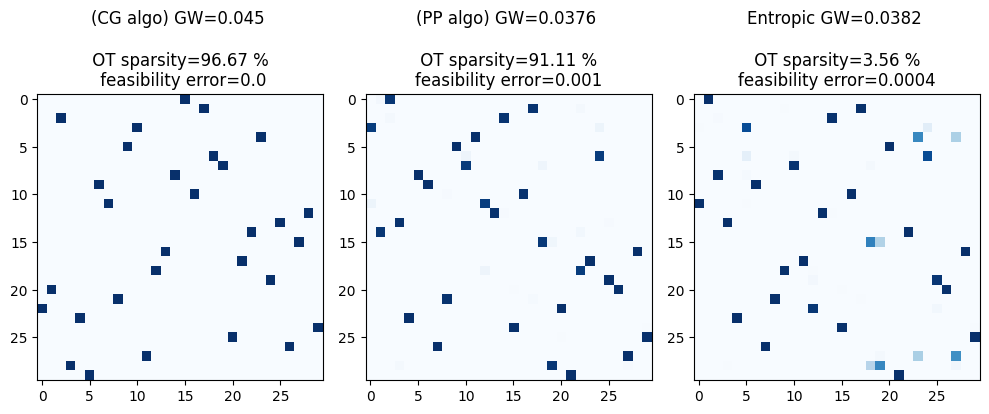

In [7]:
p = ot.unif(n_samples)
q = ot.unif(n_samples)

# Conditional Gradient algorithm
gw0, log0 = ot.gromov.gromov_wasserstein(
    C1, C2, p, q, "square_loss", verbose=True, log=True
)

# Proximal Point algorithm with Kullback-Leibler as proximal operator
gw, log = ot.gromov.entropic_gromov_wasserstein(
    C1, C2, p, q, "square_loss", epsilon=5e-4, solver="PPA", log=True, verbose=True
)

# Projected Gradient algorithm with entropic regularization
gwe, loge = ot.gromov.entropic_gromov_wasserstein(
    C1, C2, p, q, "square_loss", epsilon=5e-4, solver="PGD", log=True, verbose=True
)

print(
    "Gromov-Wasserstein distance estimated with Conditional Gradient solver: "
    + str(log0["gw_dist"])
)
print(
    "Gromov-Wasserstein distance estimated with Proximal Point solver: "
    + str(log["gw_dist"])
)
print(
    "Entropic Gromov-Wasserstein distance estimated with Projected Gradient solver: "
    + str(loge["gw_dist"])
)

# compute OT sparsity level
gw0_sparsity = 100 * (gw0 == 0.0).astype(np.float64).sum() / (n_samples**2)
gw_sparsity = 100 * (gw == 0.0).astype(np.float64).sum() / (n_samples**2)
gwe_sparsity = 100 * (gwe == 0.0).astype(np.float64).sum() / (n_samples**2)

# Methods using Sinkhorn projections tend to produce feasibility errors on the
# marginal constraints

err0 = np.linalg.norm(gw0.sum(1) - p) + np.linalg.norm(gw0.sum(0) - q)
err = np.linalg.norm(gw.sum(1) - p) + np.linalg.norm(gw.sum(0) - q)
erre = np.linalg.norm(gwe.sum(1) - p) + np.linalg.norm(gwe.sum(0) - q)

pl.figure(3, (10, 6))
cmap = "Blues"
fontsize = 12
pl.subplot(131)
pl.imshow(gw0, cmap=cmap)
pl.title(
    "(CG algo) GW=%s \n  \n OT sparsity=%s \n feasibility error=%s"
    % (
        np.round(log0["gw_dist"], 4),
        str(np.round(gw0_sparsity, 2)) + " %",
        np.round(np.round(err0, 4)),
    ),
    fontsize=fontsize,
)

pl.subplot(132)
pl.imshow(gw, cmap=cmap)
pl.title(
    "(PP algo) GW=%s \n  \n OT sparsity=%s \nfeasibility error=%s"
    % (
        np.round(log["gw_dist"], 4),
        str(np.round(gw_sparsity, 2)) + " %",
        np.round(err, 4),
    ),
    fontsize=fontsize,
)

pl.subplot(133)
pl.imshow(gwe, cmap=cmap)
pl.title(
    "Entropic GW=%s \n  \n OT sparsity=%s \nfeasibility error=%s"
    % (
        np.round(loge["gw_dist"], 4),
        str(np.round(gwe_sparsity, 2)) + " %",
        np.round(erre, 4),
    ),
    fontsize=fontsize,
)

pl.tight_layout()
pl.show()

Pointwise Gromov-Wasserstein distance estimated: 0.18551015414186553
Variance estimated: 0.0
Sampled Gromov-Wasserstein distance: 0.14981263716330115
Variance estimated: 0.0013724960658236956


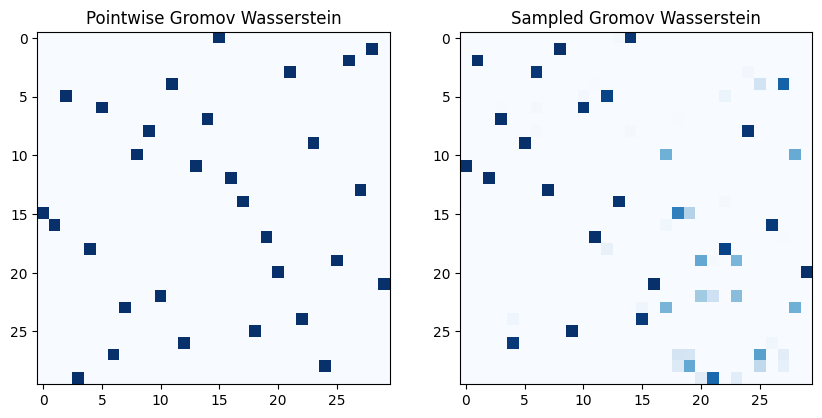

In [8]:
def loss(x, y):
    return np.abs(x - y)


pgw, plog = ot.gromov.pointwise_gromov_wasserstein(
    C1, C2, p, q, loss, max_iter=100, log=True
)

sgw, slog = ot.gromov.sampled_gromov_wasserstein(
    C1, C2, p, q, loss, epsilon=0.1, max_iter=100, log=True
)

print(
    "Pointwise Gromov-Wasserstein distance estimated: " + str(plog["gw_dist_estimated"])
)
print("Variance estimated: " + str(plog["gw_dist_std"]))
print("Sampled Gromov-Wasserstein distance: " + str(slog["gw_dist_estimated"]))
print("Variance estimated: " + str(slog["gw_dist_std"]))


pl.figure(4, (10, 5))

pl.subplot(121)
pl.imshow(pgw.toarray(), cmap=cmap)
pl.title("Pointwise Gromov Wasserstein")

pl.subplot(122)
pl.imshow(sgw, cmap=cmap)
pl.title("Sampled Gromov Wasserstein")

pl.show()